# TB4 - Analisis RFM Airbnb Trust & Safety


La unidad de analisis es `listing_id`.

- **Recency:** dias desde la ultima review observada.
- **Frequency:** cantidad de reviews observadas.
- **Monetary proxy:** `price * observed_reviews`. No representa ingresos reales.
- **Riesgo Trust & Safety:** `risk_score` y `risk_segment` del mart analitico del proyecto.

El objetivo es priorizar listings y mercados para acciones de Trust & Safety, operaciones y crecimiento sin afirmar ingresos reales ni reduccion de disputas.

## 1. Preparacion del entorno

Se usa el script reproducible `scripts/build_tb4_rfm_airbnb.py`, que genera las tablas, graficos y el resumen ejecutivo en `outputs/tb4_rfm/`.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts" / "build_tb4_rfm_airbnb.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tb4_rfm"
SCRIPT_PATH = PROJECT_ROOT / "scripts" / "build_tb4_rfm_airbnb.py"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Salida TB4: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Proyecto: C:\Development\ANALISISEMPRESAR-DATASCIENCE-AIRBNB\AirBnB-Analisis-Empresarial
Salida TB4: outputs\tb4_rfm


In [2]:
resultado = subprocess.run(
    [sys.executable, str(SCRIPT_PATH)],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=True,
)

print("Pipeline TB4 ejecutado correctamente.")
print("Archivos generados en outputs/tb4_rfm/")

Pipeline TB4 ejecutado correctamente.
Archivos generados en outputs/tb4_rfm/


## 2. Validacion de datos disponibles

El pipeline valida las fuentes principales del proyecto: `listings`, `reviews`, `listing_trust_risk` y resumenes de riesgo por mercado/segmento cuando existen.

In [3]:
tabla_validacion = pd.read_csv(OUTPUT_DIR / "tabla_validacion_datos.csv")
tabla_general = pd.read_csv(OUTPUT_DIR / "tabla_rfm_general.csv")

display(tabla_validacion)
display(tabla_general)

,dataset,path,rows,columns
0,listings,data/gold/listings.parquet,136615,"listing_id, name, host_id, host_name, room_typ..."
1,reviews,data/gold/reviews.parquet,5361259,"listing_id, review_id, review_date, comment_le..."
2,listing_trust_risk,data/gold/analytics/listing_trust_risk.parquet,136615,"listing_id, country, market, market_label, ris..."
3,market_trust_risk_summary,data/gold/analytics/market_trust_risk_summary....,7,"country, market, market_label, listings, avg_r..."
4,risk_segment_summary,data/gold/analytics/risk_segment_summary.parquet,3,"risk_segment, listings, avg_risk_score, avg_tr..."


,total_listings,listings_con_reviews,reviews_procesadas,min_review_date,max_review_date,reference_date,meses_disponibles,promedio_recency,promedio_frequency,promedio_monetary_proxy,price_missing_rate,price_outlier_rate
0,136615,111624,5361259,2010-06-07,2026-02-14,2026-02-15,189,"1,245.76",39.24,"160,657.92",0.34,0.01


**Resultado temporal usado en TB4**

- Rango de reviews: **2010-06-07 a 2026-02-14**.
- Fecha de corte RFM: **2026-02-15**, calculada como `max(review_date) + 1 dia`.
- Reviews procesadas: **5,361,259**.
- Listings procesados: **136,615**.
- Listings con al menos una review: **111,624**.
- Meses disponibles: **189**.

## 3. Definicion de variables RFM

| Variable | Definicion | Interpretacion |
|---|---|---|
| `recency_days` | Dias desde la ultima review hasta la fecha de corte | Menor valor indica actividad mas reciente |
| `frequency` | Cantidad de reviews observadas por listing | Proxy de actividad posterior a reserva |
| `monetary_proxy` | `price * observed_reviews` | Proxy monetario; no es revenue real |
| `R_score` | Score de recencia de 1 a 5 | 5 es mejor |
| `F_score` | Score de frecuencia de 1 a 5 | 5 es mejor |
| `M_score` | Score monetario proxy de 1 a 5 | 5 es mejor |
| `rfm_total_score` | `R_score + F_score + M_score` | Score total entre 3 y 15 |
| `rfm_segment` | Segmento final RFM | Grupo operativo para decision |
| `priority_segment` | Cruce RFM con riesgo Trust & Safety | Priorizacion de accion |

In [4]:
rfm = pd.read_parquet(OUTPUT_DIR / "rfm_listing_segments.parquet")

columnas_detalle = {
    "listing_id": "ID",
    "last_review_date": "FECHA",
    "recency_days": "RECENCIA",
    "frequency": "FRECUENCIA",
    "monetary_proxy": "MONTO_PROXY",
    "R_score": "R_QUARTIL",
    "F_score": "F_QUARTIL",
    "M_score": "M_QUARTIL",
    "rfm_total_score": "RFM_SCORE",
    "rfm_segment": "SEGMENTO_RFM",
    "risk_segment": "RIESGO_T_S",
    "priority_segment": "PRIORIDAD_ACCION",
}

detalle_rfm = rfm[list(columnas_detalle)].rename(columns=columnas_detalle).copy()
detalle_rfm["FECHA"] = pd.to_datetime(detalle_rfm["FECHA"], errors="coerce").dt.date
display(detalle_rfm.head(20))

,ID,FECHA,RECENCIA,FRECUENCIA,MONTO_PROXY,R_QUARTIL,F_QUARTIL,M_QUARTIL,RFM_SCORE,SEGMENTO_RFM,RIESGO_T_S,PRIORIDAD_ACCION
0,14551,2025-09-13,155.00,83,0.00,4,5,1,10,Frecuentes de bajo valor,Low,Monitoreo bajo
1,17878,2025-09-17,151.00,341,"121,396.00",4,5,5,14,Champions / Alto valor activo,Low,Proteger y retener
2,18674,2025-11-19,88.00,54,0.00,5,4,1,10,Frecuentes de bajo valor,Low,Monitoreo bajo
3,23197,2025-10-08,130.00,92,0.00,5,5,1,11,Frecuentes de bajo valor,Low,Monitoreo bajo
4,25026,2025-09-04,164.00,313,"79,815.00",4,5,5,14,Champions / Alto valor activo,Low,Proteger y retener
5,32711,2025-11-22,85.00,155,0.00,5,5,1,11,Frecuentes de bajo valor,Low,Monitoreo bajo
6,34981,2025-11-24,83.00,282,0.00,5,5,1,11,Frecuentes de bajo valor,Low,Monitoreo bajo
7,35764,2025-09-17,151.00,527,"120,156.00",4,5,5,14,Champions / Alto valor activo,Low,Proteger y retener
8,35797,NaT,"5,352.00",0,0.00,1,1,1,3,Dormidos,High,Bajo valor pero riesgoso
9,36763,2023-12-13,795.00,108,0.00,2,5,1,8,Valor medio operativo,Low,Monitoreo bajo


## 4. Segmentos RFM obtenidos

La tabla resume cantidad de listings, porcentaje, recencia promedio, frecuencia promedio, proxy monetario promedio, riesgo promedio y porcentaje de listings High/Critical.

In [5]:
tabla_segmentos = pd.read_csv(OUTPUT_DIR / "tabla_rfm_segmentos.csv")
display(tabla_segmentos)

,rfm_segment,cantidad_listings,recency_promedio,frequency_promedio,monetary_proxy_promedio,rfm_promedio,risk_score_promedio,high_critical_pct,porcentaje
0,Valor medio operativo,43514,329.89,25.29,"122,316.11",9.02,11.80,0.13,31.85
1,Dormidos,40201,"3,651.29",0.87,"1,889.62",4.17,40.18,30.79,29.43
2,Champions / Alto valor activo,24656,153.14,101.05,"595,080.11",13.52,3.66,0.00,18.05
3,Frecuentes de bajo valor,12579,116.84,113.84,0.00,10.13,9.20,0.00,9.21
4,Potenciales en crecimiento,11869,153.50,8.15,"63,693.39",10.85,8.75,0.03,8.69
5,Alto valor en riesgo,3752,526.66,54.71,"298,921.02",10.69,8.97,0.00,2.75
6,Nuevos o poca evidencia,44,137.50,1.00,701.84,7.07,24.54,2.27,0.03


**Lectura ejecutiva**

- `Valor medio operativo` es el segmento mas grande: **43,514 listings (31.85%)**.
- `Dormidos` concentra **40,201 listings (29.43%)** y tiene el mayor riesgo promedio: **40.18**.
- `Champions / Alto valor activo` agrupa **24,656 listings (18.05%)** con alta frecuencia promedio (**101.05**) y bajo riesgo promedio (**3.66**).
- El segmento `Dormidos` concentra la mayor tasa High/Critical: **30.79%**.

## 5. Resultado por mercado

La tabla muestra el segmento dominante por mercado, el RFM promedio, el riesgo promedio y el porcentaje High/Critical.

In [6]:
tabla_mercado = pd.read_csv(OUTPUT_DIR / "tabla_rfm_mercado.csv")
display(tabla_mercado)

,country,market_label,listings,segmento_dominante,rfm_promedio,risk_score_promedio,high_critical_pct,monetary_proxy_promedio,prioridad_critica
0,Japan,Tokyo,27945,Valor medio operativo,10.44,12.92,1.32,"704,329.48",0
1,United States,Asheville,2852,Valor medio operativo,10.20,9.76,2.98,"14,488.69",0
2,Mexico,Mexico City,27051,Champions / Alto valor activo,9.92,13.98,5.73,"66,673.62",0
3,United States,New Orleans,453,Frecuentes de bajo valor,8.31,16.13,7.51,0.00,0
4,Brazil,Rio de Janeiro,43068,Dormidos,8.22,19.96,12.40,"9,772.57",0
5,Spain,Girona / Costa Brava,17069,Valor medio operativo,6.93,20.99,9.89,0.00,0
6,Spain,Barcelona,18177,Dormidos,6.86,26.48,18.56,0.00,0


**Lectura por mercado**

- `Tokyo` tiene el mayor RFM promedio (**10.44**) y bajo porcentaje High/Critical (**1.32%**).
- `Mexico City` aparece con segmento dominante `Champions / Alto valor activo` y RFM promedio **9.92**.
- `Barcelona` tiene el mayor riesgo promedio (**26.48**) y el mayor porcentaje High/Critical (**18.56%**).
- `Rio de Janeiro` tiene el mayor volumen de listings (**43,068**) y segmento dominante `Dormidos`.

## 6. Cruce RFM con Trust & Safety

El cruce RFM x riesgo genera segmentos de prioridad para decidir acciones operativas.

In [7]:
tabla_prioridad = pd.read_csv(OUTPUT_DIR / "tabla_prioridad_accion.csv")
display(tabla_prioridad)

,priority_segment,cantidad,porcentaje,accion_recomendada
0,Monitoreo bajo,88373,64.69,Seguimiento ligero; priorizar solo si cambia a...
1,Proteger y retener,35801,26.21,"Mantener visibilidad, monitorear calidad y pro..."
2,Bajo valor pero riesgoso,12392,9.07,"Depurar, corregir datos minimos o mantener mon..."
3,Corregir antes de escalar,49,0.04,Aplicar mejoras de calidad/verificacion antes ...
4,Prioridad critica,0,0.00,Revision Trust & Safety inmediata; corregir co...


**Interpretacion de prioridad**

- `Monitoreo bajo`: **88,373 listings (64.69%)**.
- `Proteger y retener`: **35,801 listings (26.21%)**.
- `Bajo valor pero riesgoso`: **12,392 listings (9.07%)**.
- `Corregir antes de escalar`: **49 listings (0.04%)**.
- `Prioridad critica`: **0 listings** bajo la regla definida de RFM alto + riesgo High/Critical.

## 7. Visualizaciones principales

Los graficos se guardan en `outputs/tb4_rfm/` y se muestran a continuacion.

### reviews_por_mes.png

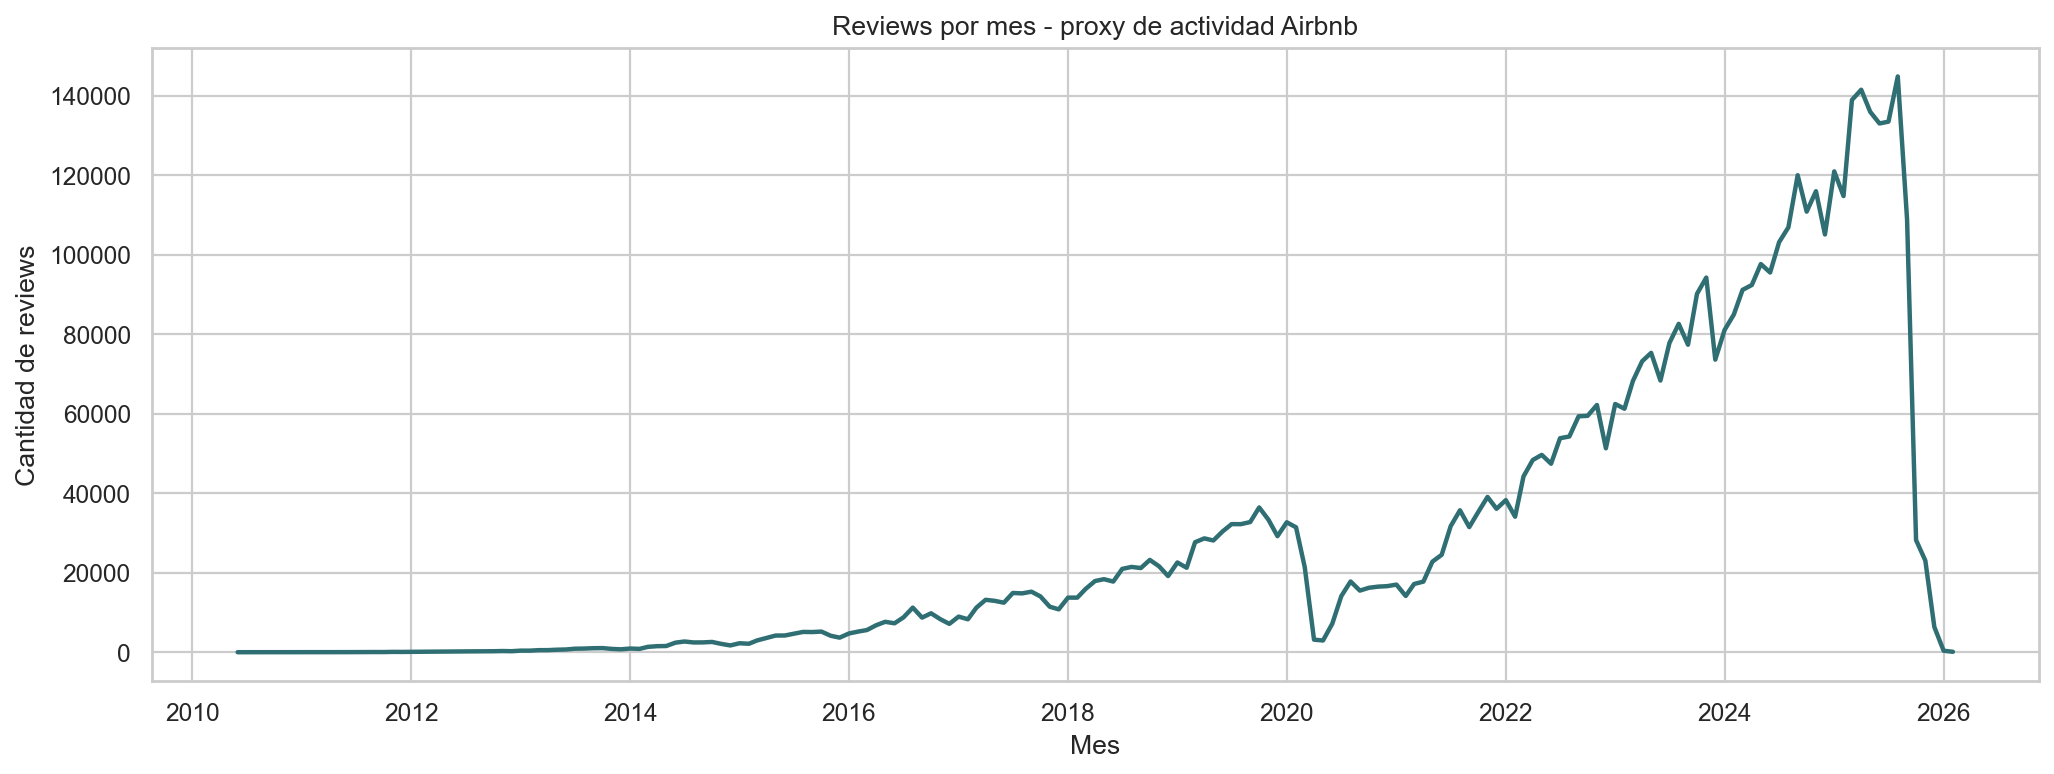

### distribucion_segmentos_rfm.png

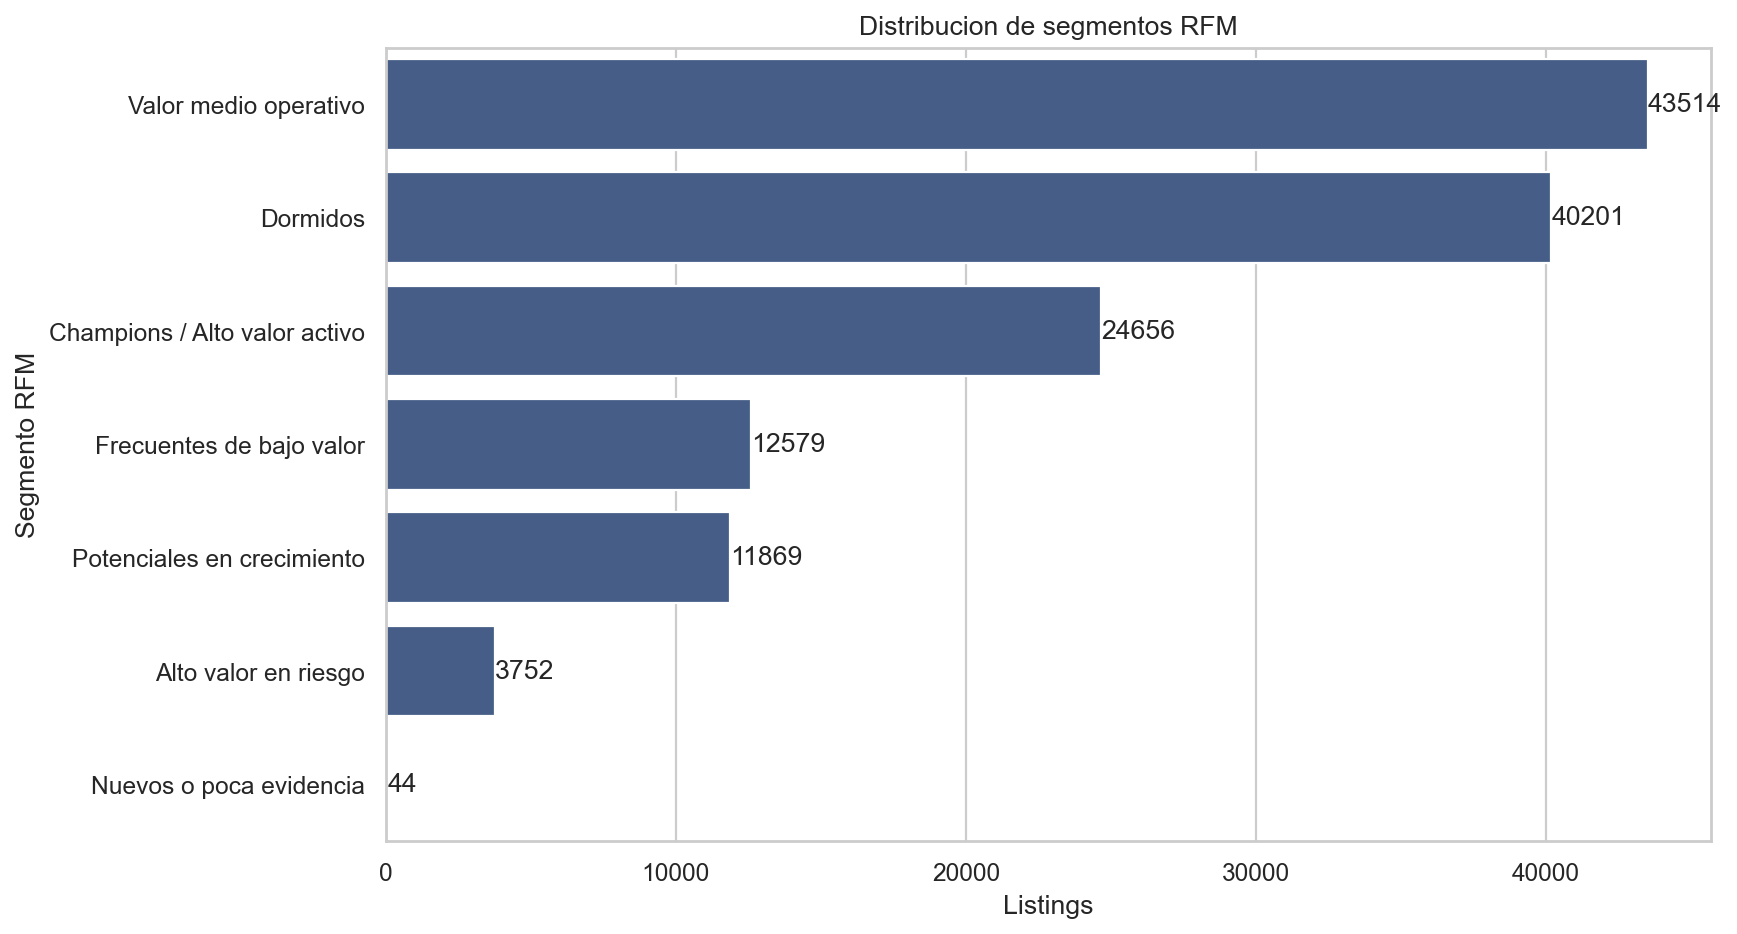

### rfm_vs_risk_score.png

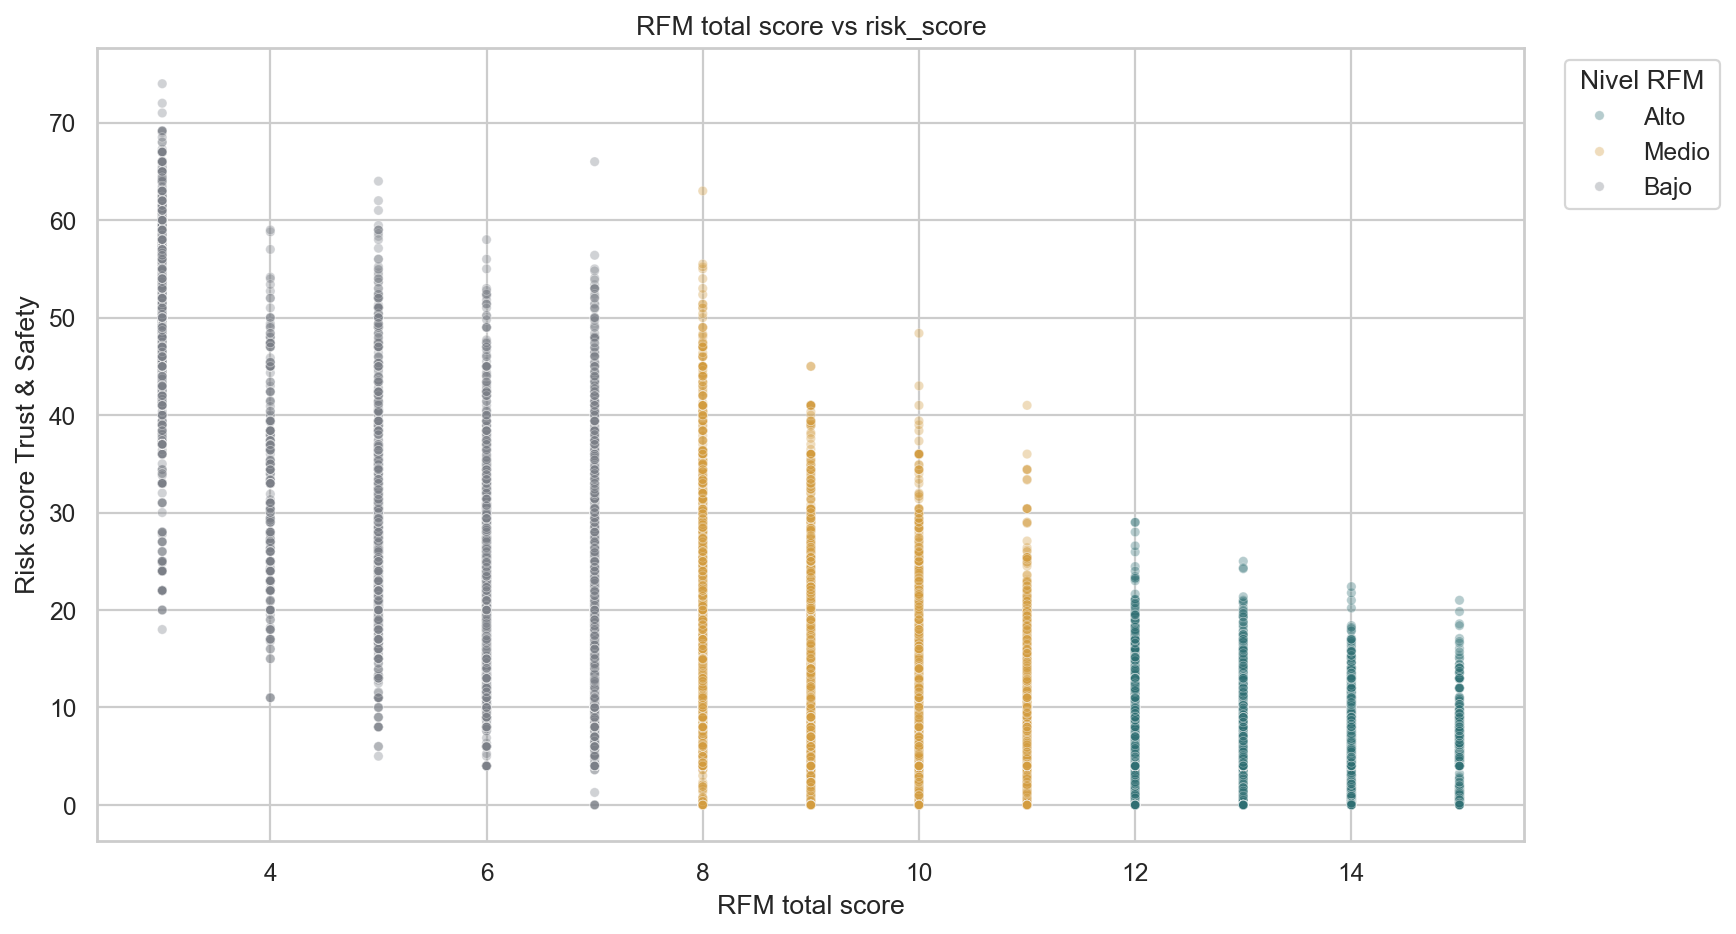

### top_mercados_high_value_risk.png

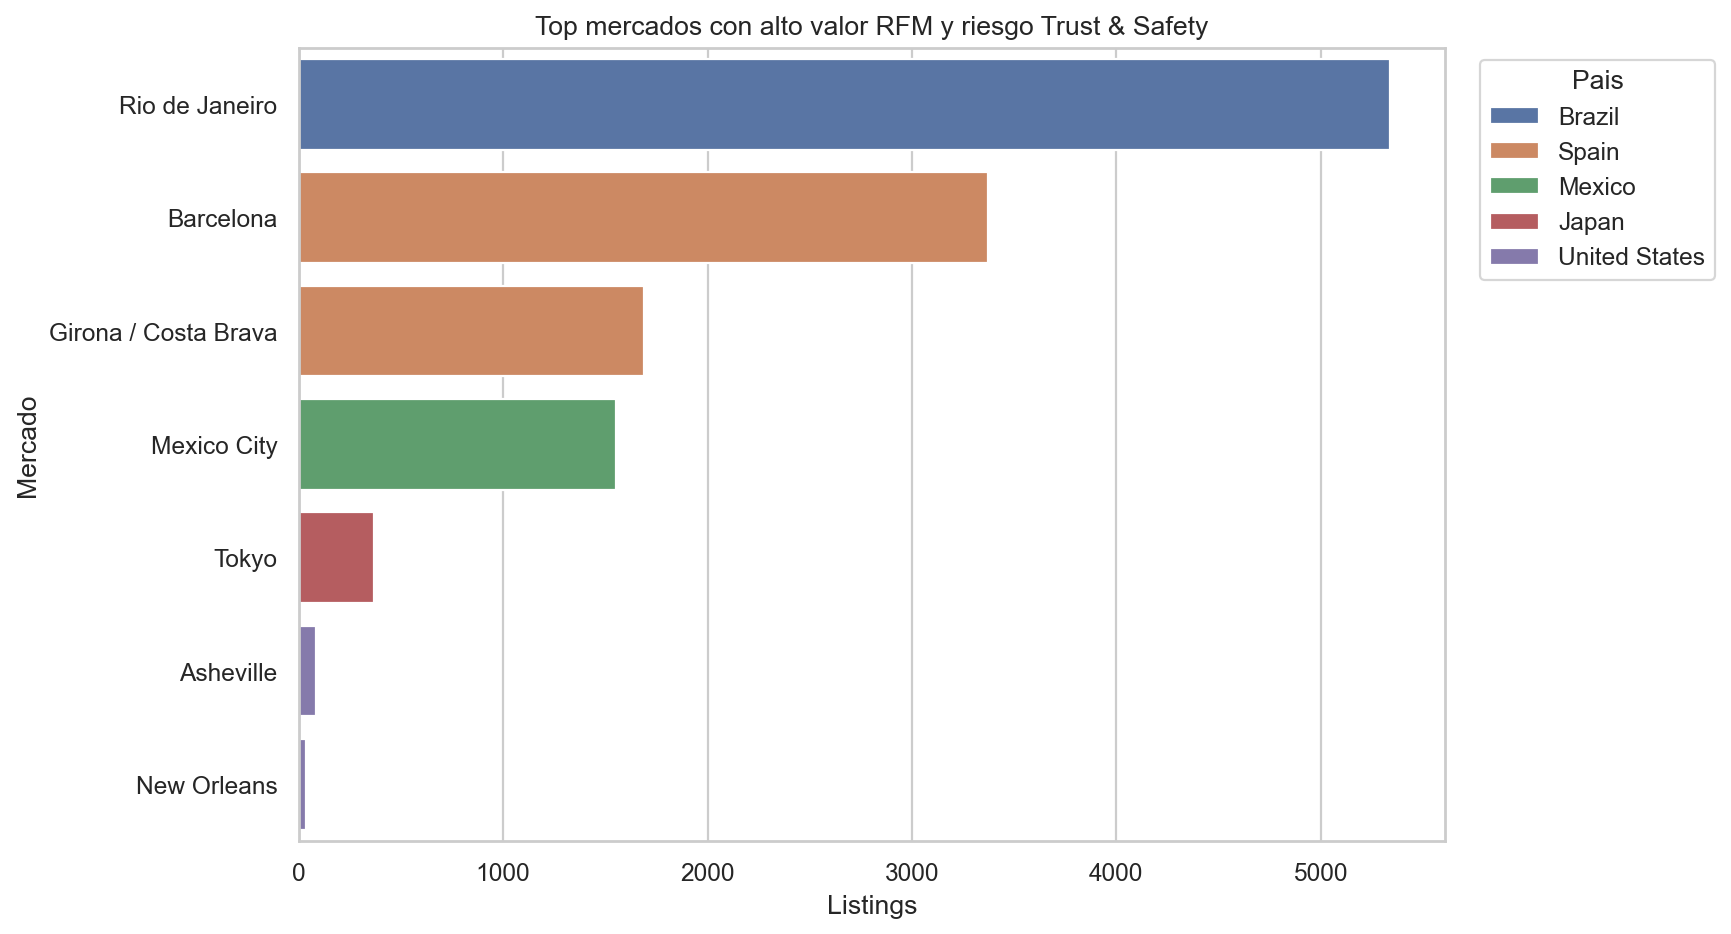

In [8]:
imagenes = [
    "reviews_por_mes.png",
    "distribucion_segmentos_rfm.png",
    "rfm_vs_risk_score.png",
    "top_mercados_high_value_risk.png",
]

for imagen in imagenes:
    display(Markdown(f"### {imagen}"))
    display(Image(filename=str(OUTPUT_DIR / imagen)))

## 8. Matriz RFM: Recency x Frequency x Monetary

La matriz cruza `R_score` y `F_score`; el color representa el `M_score` promedio. Sirve para ver donde se concentran los listings segun recencia, frecuencia y proxy monetario.

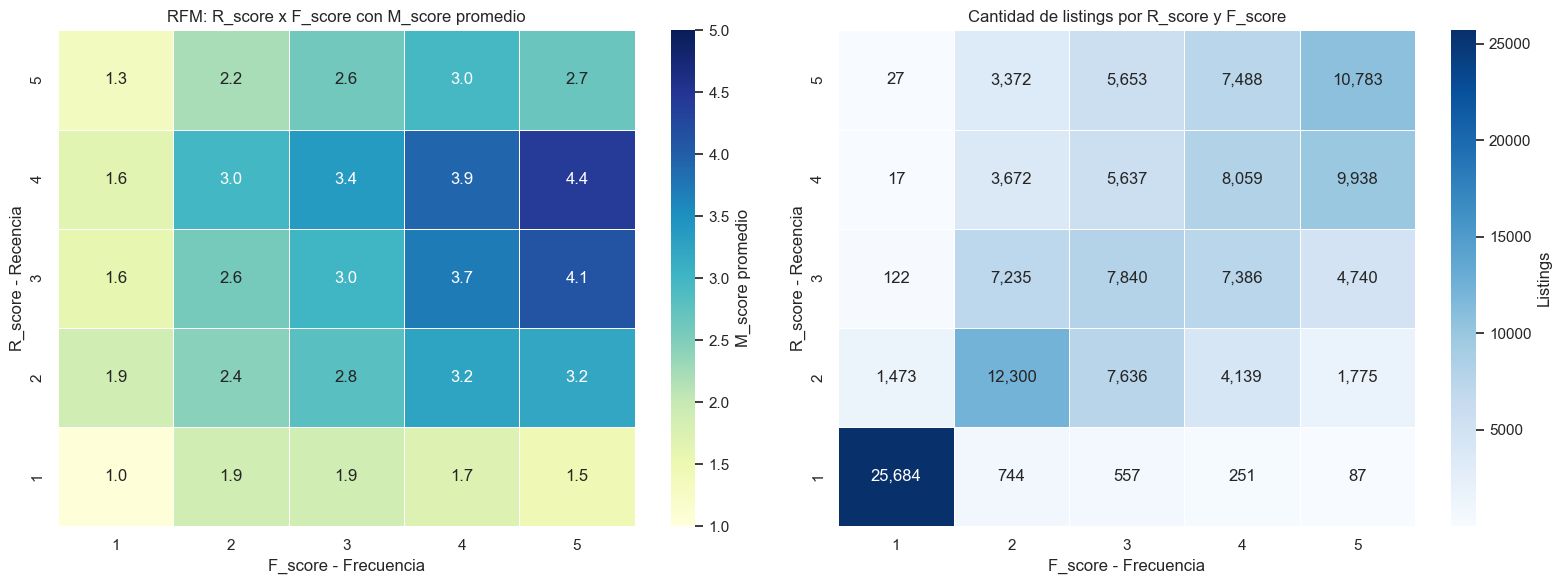

Grafico guardado: outputs\tb4_rfm\matriz_rfm_recency_frequency_monetary.png


In [9]:
matriz_base = (
    rfm.groupby(["R_score", "F_score"], dropna=False)
    .agg(
        listings=("listing_id", "count"),
        M_score_promedio=("M_score", "mean"),
        RFM_score_promedio=("rfm_total_score", "mean"),
    )
    .reset_index()
)

score_order = [1, 2, 3, 4, 5]
recency_order = [5, 4, 3, 2, 1]

matriz_m = (
    matriz_base
    .pivot(index="R_score", columns="F_score", values="M_score_promedio")
    .reindex(index=recency_order, columns=score_order)
)

matriz_listings = (
    matriz_base
    .pivot(index="R_score", columns="F_score", values="listings")
    .reindex(index=recency_order, columns=score_order)
    .fillna(0)
    .astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    matriz_m,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=1,
    vmax=5,
    linewidths=0.5,
    cbar_kws={"label": "M_score promedio"},
    ax=axes[0],
)
axes[0].set_title("RFM: R_score x F_score con M_score promedio")
axes[0].set_xlabel("F_score - Frecuencia")
axes[0].set_ylabel("R_score - Recencia")

sns.heatmap(
    matriz_listings,
    annot=True,
    fmt=",d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Listings"},
    ax=axes[1],
)
axes[1].set_title("Cantidad de listings por R_score y F_score")
axes[1].set_xlabel("F_score - Frecuencia")
axes[1].set_ylabel("R_score - Recencia")

plt.tight_layout()
matrix_path = OUTPUT_DIR / "matriz_rfm_recency_frequency_monetary.png"
plt.savefig(matrix_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Grafico guardado: {matrix_path.relative_to(PROJECT_ROOT)}")

## 9. Conclusiones para TB4

El analisis RFM permite priorizar listings segun actividad reciente, frecuencia de reviews y valor monetario proxy. Al cruzarlo con `risk_segment`, el proyecto separa acciones comerciales de acciones de confianza:

- Los listings `Champions / Alto valor activo` deben protegerse y monitorearse porque aportan alta actividad proxy y bajo riesgo promedio.
- Los listings `Dormidos` requieren revision, porque combinan baja actividad con mayor riesgo promedio.
- Los mercados con mayor riesgo relativo, como Barcelona, deben recibir atencion operativa y de calidad antes de impulsar demanda.
- El RFM complementa el modelo de riesgo de TB3: no reemplaza la prediccion de riesgo, sino que ayuda a ordenar prioridades por valor operativo.

**Limitaciones:** no existen reservas, pagos ni disputas reales en el repositorio. Las reviews son proxy de actividad y `monetary_proxy` no debe presentarse como ingresos reales.